# Milestone 1: UrbanCart Finance — Predicting Next-Month Spend

UrbanCart's finance team wants to estimate how much a customer will spend next month so they can plan inventory and cash flow.

This is a **regression** problem, not classification, because the target `NextMonthSpend` is a dollar amount. Classification would only answer a yes/no or high/low question. Finance needs a number.

**Approach**
1. Check data quality
2. Look at outliers, but keep them
3. See which features actually move next-month spend
4. Add one extra feature: recent spend volume
5. Encode `Region`
6. Train/test split **before** fitting any model
7. Score each model on train and test
8. Compare Linear Regression and Random Forest
9. Recommend one model with a tradeoff


## 1. Setup

Load the libraries used for tables, plots, and models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make tables show more columns
pd.set_option("display.max_columns", None)

# make plots a bit nicer
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load the data

Read the customer file into a table called `df`. Each row is one customer.


In [2]:
df = pd.read_csv("milestone-1-customer-spend.csv")


Look at size, the first rows, and the average customer. This is so we know what a normal value looks like before checking missing cells.


In [ ]:
print("Shape:", df.shape)
print(df.head())
print(df.describe())
print("Customers per Region:")
print(df["Region"].value_counts())


## 3. Data quality check

Before modeling, check for missing values, wrong types, and duplicates.

Expected columns:
- `MonthsActive`: how long the customer has been active
- `AvgOrderValue`: typical order size
- `NumOrdersLastQuarter`: how many orders in the last quarter
- `Region`: North, South, East, or West
- `NextMonthSpend`: what they actually spent the following month (the target)


In [3]:
df.isna().sum()

MonthsActive            0
AvgOrderValue           0
NumOrdersLastQuarter    0
Region                  0
NextMonthSpend          0
dtype: int64

**Dtypes.** Counts should be integers. Money should be floats. `Region` should be text.


In [4]:
df.dtypes

MonthsActive              int64
AvgOrderValue           float64
NumOrdersLastQuarter      int64
Region                      str
NextMonthSpend          float64
dtype: object

**Missing values, duplicates, and uniqueness.**  
0 missing and 0 duplicates means the file is structurally clean. 4 unique regions is what we want.


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique values per column:")
print(df.nunique())


Missing values per column:
MonthsActive            0
AvgOrderValue           0
NumOrdersLastQuarter    0
Region                  0
NextMonthSpend          0
dtype: int64

Duplicate rows: 0

Unique values per column:
MonthsActive              60
AvgOrderValue           7929
NumOrdersLastQuarter      14
Region                     4
NextMonthSpend          9354
dtype: int64


## 4. Outliers

An outlier is a value far from most of the others. Here that usually means high spenders or frequent buyers.

The boxplot is a quick picture: dots outside the whiskers are the unusual values.


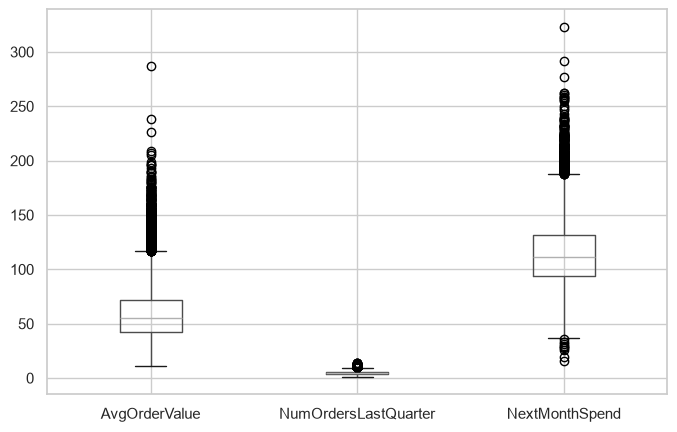

In [6]:
df[["AvgOrderValue", "NumOrdersLastQuarter", "NextMonthSpend"]].boxplot()
plt.show()

### IQR fence

The common rule is:

- $Q1$ = 25th percentile
- $Q3$ = 75th percentile
- $IQR = Q3 - Q1$
- lower fence = $Q1 - 1.5 \times IQR$
- upper fence = $Q3 + 1.5 \times IQR$

Anything outside that fence is flagged as an outlier.  
This cell only **counts** them. It does not change the data.


In [7]:
cols = ["MonthsActive", "AvgOrderValue", "NumOrdersLastQuarter", "NextMonthSpend"]

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col)
    print("normal range:", round(lower, 2), "to", round(upper, 2))
    print("outliers:", n)
    print()

MonthsActive
normal range: -30.0 to 90.0
outliers: 0

AvgOrderValue
normal range: -3.11 to 116.94
outliers: 620

NumOrdersLastQuarter
normal range: 1.0 to 9.0
outliers: 416

NextMonthSpend
normal range: 37.05 to 187.93
outliers: 340



**Decision.** Outliers exist, mostly high spenders and frequent buyers. I am keeping them because they look valid and finance needs those customers in the forecast.

I am not using `clip()` to cap them. Capping `NextMonthSpend` would change the thing we are trying to predict.


## 5. How the features relate to spend

Cleaning only says the file is usable. These plots show which columns actually move `NextMonthSpend`.


Distributions. This is so we can see the shape of each column, including the high-spend tail.


In [ ]:
df[["MonthsActive", "AvgOrderValue", "NumOrdersLastQuarter", "NextMonthSpend"]].hist(
    bins=30, figsize=(10, 8)
)
plt.suptitle("Distribution of numeric columns")
plt.tight_layout()
plt.show()

Correlation. A number near 1 means the column rises with next-month spend. Near 0 means almost no linear link.


In [ ]:
corr = df.corr(numeric_only=True)
print(corr["NextMonthSpend"].sort_values(ascending=False))

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

Each chart is one feature against `NextMonthSpend`. A clear upward slope means that feature is useful.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ["AvgOrderValue", "NumOrdersLastQuarter", "MonthsActive"]

for ax, col in zip(axes, features):
    ax.scatter(df[col], df["NextMonthSpend"], alpha=0.15)
    ax.set_xlabel(col)
    ax.set_ylabel("NextMonthSpend")
    ax.set_title(col + " vs next-month spend")

plt.tight_layout()
plt.show()

Spend by region. If the boxes sit at different heights, `Region` belongs in the model.


In [ ]:
print(df.groupby("Region")["NextMonthSpend"].agg(["mean", "median", "count"]))

sns.boxplot(data=df, x="Region", y="NextMonthSpend")
plt.title("Next-month spend by region")
plt.show()

`AvgOrderValue` has the strongest link with next-month spend (about 0.76). `NumOrdersLastQuarter` is moderate (about 0.41). `MonthsActive` is weak (about 0.17). North customers spend more on average than West, so region stays in.


### Extra feature

`ExpectedQuarterSpend` is `AvgOrderValue × NumOrdersLastQuarter`. That product is recent spend volume. Check its correlation before putting it into `X`.


In [ ]:
df["ExpectedQuarterSpend"] = df["AvgOrderValue"] * df["NumOrdersLastQuarter"]

print("Correlation with NextMonthSpend:")
print(
    df[["MonthsActive", "AvgOrderValue", "NumOrdersLastQuarter",
        "ExpectedQuarterSpend", "NextMonthSpend"]]
    .corr()["NextMonthSpend"]
    .sort_values(ascending=False)
)

## 6. Features and target

- `X` = what we already know about the customer
- `y` = `NextMonthSpend`, the value finance wants to forecast

`ExpectedQuarterSpend` is `AvgOrderValue × NumOrdersLastQuarter`. That is an estimate of recent spend volume, not a new raw column from the file.


In [8]:
X = df[["MonthsActive", "AvgOrderValue", "NumOrdersLastQuarter", "ExpectedQuarterSpend", "Region"]]
y = df["NextMonthSpend"]

print(X.head())
print(y.head())


   MonthsActive  AvgOrderValue  NumOrdersLastQuarter Region
0             6          25.70                     7  South
1            47          85.81                     5   East
2            40          87.63                     7   East
3            27          45.16                     4   East
4            26          67.26                     7   East
0     88.51
1    137.62
2    148.99
3    101.25
4    136.76
Name: NextMonthSpend, dtype: float64


## 7. Encode `Region`

Models cannot use the text `"South"`. `get_dummies` turns region into 0/1 columns.

`drop_first=True` drops one region (East) so we do not repeat the same information. If North, South, and West are all 0, the customer is East.


In [9]:
X = pd.get_dummies(X, columns=["Region"], drop_first=True)
print(X.head())

   MonthsActive  AvgOrderValue  NumOrdersLastQuarter  Region_North  \
0             6          25.70                     7         False   
1            47          85.81                     5         False   
2            40          87.63                     7         False   
3            27          45.16                     4         False   
4            26          67.26                     7         False   

   Region_South  Region_West  
0          True        False  
1         False        False  
2         False        False  
3         False        False  
4         False        False  


## 8. Train/test split

Split **before** training. This is so the test score is honest.

- **Train set (80%)**: the 16,000 rows the model is allowed to study
- **Test set (20%)**: the 4,000 rows held back, like an unseen exam

`random_state=42` makes the split the same every time the notebook is rerun.

No test row is used to fit or tune the model.


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Train rows: 16000
Test rows: 4000


## 9. Model 1 — Linear Regression

Linear Regression learns one number (coefficient) for each feature and adds them up:

next-month spend ≈ intercept + tenure effect + average-order effect + recent-orders effect + recent-volume effect + region effect

It is simple and easy for finance to interpret. `fit` is done on the **train set only**.


In [11]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.27, 0.9 , 5.94,10.02,-4.89,-9.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['MonthsActive','AvgOrderValue','NumOrdersLastQuarter','Region_North', 'Region_South','Region_West']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.87
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


Predict the train rows and the held-out test customers. Train scores show whether the model memorized the data. Test scores show how it does on new customers.


In [12]:
y_pred_lin_train = lin.predict(X_train)
y_pred_lin = lin.predict(X_test)

print("Actual:", y_test.head(10).tolist())
print("Predicted:", y_pred_lin[:10])


Actual: [109.19, 182.15, 154.37, 77.07, 134.71, 145.89, 191.69, 61.89, 107.85, 59.38]
Predicted: [ 93.78066815 198.20099231 161.44414664  77.85016719 136.71883854
 164.3679506  179.58086602  91.12081058  90.49972935  73.50224244]


### Train and test metrics

These scores are computed on train and on test.

- **MAE**: average error in dollars. Lower is better.
- **RMSE**: like MAE, but large mistakes count more. Lower is better.
- **R²**: share of spend variation the model explains. 0 = no better than guessing the average. 1 = perfect. Higher is better.

If train R² is much higher than test R², the model overfit.


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def print_scores(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(label)
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2  :", round(r2, 3))
    print()

print_scores(y_train, y_pred_lin_train, "Linear Regression — TRAIN")
print_scores(y_test, y_pred_lin, "Linear Regression — TEST")


Linear Regression
MAE : 9.85
RMSE: 12.33
R2  : 0.83


### Actual vs predicted plot

Each dot is one test customer. The red line is a perfect prediction (`predicted = actual`). Dots near the line are good guesses.


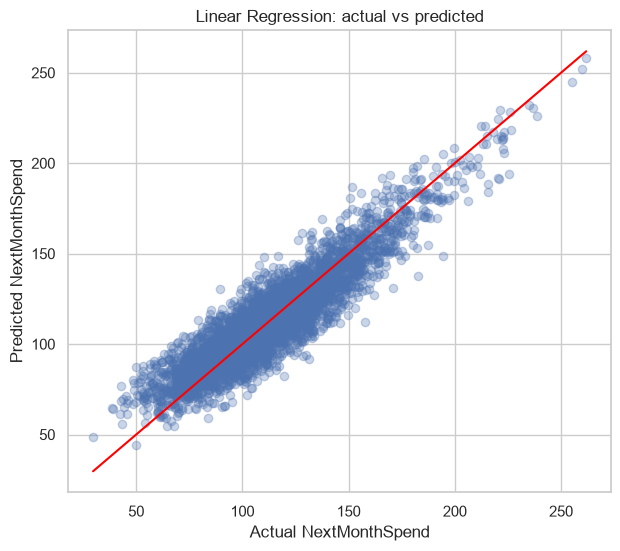

In [14]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual NextMonthSpend")
plt.ylabel("Predicted NextMonthSpend")
plt.title("Linear Regression: actual vs predicted")
plt.show()

Linear Regression follows actual next-month spend well for typical customers. It under-predicts some high spenders and slightly over-predicts some low spenders

### Residual plots

A residual is `actual - predicted`.

- Centered on 0 means the model is not systematically too high or too low
- A wide spread means larger typical errors
- Residual vs predicted shows *where* the misses happen, not only how big they are


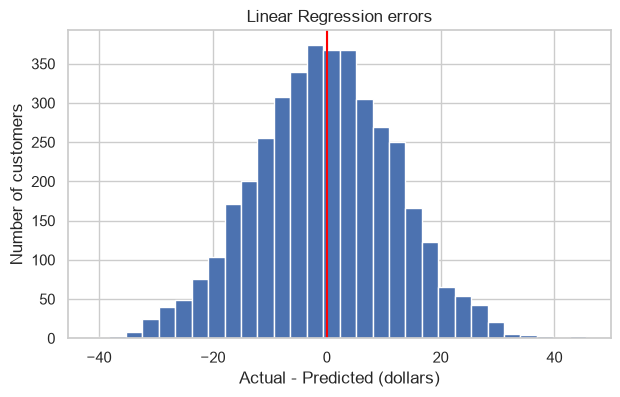

In [15]:
residuals = y_test - y_pred_lin

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_lin, residuals, alpha=0.3)
plt.axhline(0, color="red")
plt.xlabel("Predicted NextMonthSpend")
plt.ylabel("Actual - Predicted")
plt.title("Linear Regression: residuals vs predicted")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=30)
plt.axvline(0, color="red")
plt.xlabel("Actual - Predicted (dollars)")
plt.ylabel("Number of customers")
plt.title("Linear Regression errors")
plt.show()


## 10. Model 2 — Random Forest

A Random Forest builds many decision trees and averages their guesses. It can capture non-linear patterns and unusual high spenders.

It is trained on the **same** train/test split. A new split would make the comparison unfair.

- `n_estimators=100`: 100 trees
- `random_state=42`: reproducible
- `n_jobs=-1`: use all CPU cores


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

Predict the same train and test customers so we can compare the two models side by side.


In [17]:
y_pred_rf_train = rf.predict(X_train)
y_pred_rf = rf.predict(X_test)

print("Actual:", y_test.head().tolist())
print("Linear:", y_pred_lin[:5])
print("Forest:", y_pred_rf[:5])


Actual: [109.19, 182.15, 154.37, 77.07, 134.71]
Linear: [ 93.78066815 198.20099231 161.44414664  77.85016719 136.71883854]
Forest: [ 95.0558 200.3352 155.5913  78.4791 134.6639]


Score Random Forest with the same three metrics, on train and on the same test set.


In [18]:
print_scores(y_train, y_pred_rf_train, "Random Forest — TRAIN")
print_scores(y_test, y_pred_rf, "Random Forest — TEST")


Random Forest
MAE : 10.56
RMSE: 13.17
R2  : 0.806


Same actual-vs-predicted plot for Random Forest. Compare how tightly the dots follow the red line versus Linear Regression.


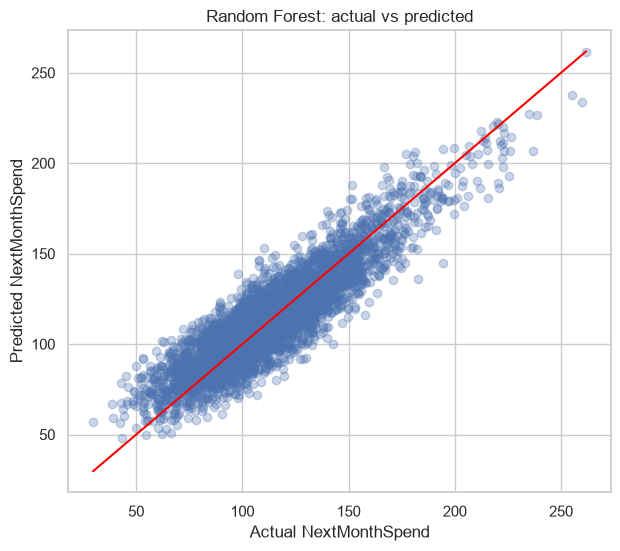

In [19]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual NextMonthSpend")
plt.ylabel("Predicted NextMonthSpend")
plt.title("Random Forest: actual vs predicted")
plt.show()

### What each model used

Coefficients are the Linear Regression weights. Importance is how much Random Forest relied on each column. This is so the EDA story can be checked against the fitted models.


In [ ]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lin.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Linear Regression intercept:", round(lin.intercept_, 2))
print(coef_df)

imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(imp_df)

plt.figure(figsize=(7, 4))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()


## 11. Comparison

| Model | Train R² | Test MAE | Test RMSE | Test R² |
|---|---|---|---|---|
| Linear Regression | 0.825 | 9.85 | 12.33 | 0.830 |
| Random Forest | 0.972 | 10.51 | 13.13 | 0.807 |

Lower MAE/RMSE is better. Higher R² is better.

**Linear Regression is better on the test set.** Train vs test is the extra check: Linear Regression stays around R² 0.83 on both sides. Random Forest jumps to R² 0.97 on train and drops on test, so it memorized training rows.

The relationship is close to linear: higher average order value and more recent orders usually mean higher next-month spend. A forest is not automatically stronger.

On the test set, Linear Regression is off by about **$10** per customer on average and explains about **83%** of the differences in spend.

`ExpectedQuarterSpend` correlates a bit more with the target than `AvgOrderValue` alone (0.80 vs 0.76). Linear Regression still barely moves after adding it, because it already had both pieces. That extra column is still useful for the forest importance plot, but it is not what makes Linear Regression win.


## 12. Recommendation

**Use Linear Regression** for next-month spend planning.

It beat Random Forest on the held-out test set (MAE about $9.85 vs $10.51, R² 0.83 vs 0.81). Train and test scores match, so the result is not from overfitting. It is also easier for finance to explain, because each feature has one coefficient.

**Tradeoff.** Random Forest can model odd non-linear cases, but here it overfit the training data and did not predict better on new customers. Linear Regression is a bit cautious on extremes: it can under-predict some very high spenders and slightly over-predict some low spenders.

**Limit.** Neither model sees “this customer went quiet.” The features are tenure, average order value, recent order count, recent spend volume, and region. A strong customer can still drop suddenly, and this model will not fully see that coming.
